# Notebook 4 — Optimisation & Déploiement
## ImmoPredict SN — GridSearch + Validation finale
---

In [1]:
import pandas as pd
import numpy as np
import json, joblib, os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import randint, uniform

GOLD='#C9A84C'; NAVY='#0F2444'; GREEN='#0E6B4A'
np.random.seed(42)

# Charger config
with open('../properties/ml/features_config.json') as f:
    cfg = json.load(f)

NUM_FEATS = cfg['NUMERIC_FEATURES']
CAT_FEATS = cfg['CATEGORICAL_FEATURES']

df = pd.read_csv('../data/dataset_features.csv')
df = df.dropna(subset=['price'])
df = df[df['price'].between(1_000_000, 2_000_000_000)]
df['log_price'] = np.log1p(df['price'])

avail_num = [f for f in NUM_FEATS if f in df.columns]
avail_cat = [f for f in CAT_FEATS if f in df.columns]
X = df[avail_num + avail_cat]
y = df['log_price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'✅ {len(df):,} annonces | Train:{len(X_train):,} Test:{len(X_test):,}')

✅ 2,768 annonces | Train:2,214 Test:554


In [2]:
# ── Préprocesseur commun ──────────────────────────────────────
num_pipe = Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())])
cat_pipe = Pipeline([('i',SimpleImputer(strategy='constant',fill_value='Autre')),
                     ('e',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])
prep = ColumnTransformer([('n',num_pipe,avail_num),('c',cat_pipe,avail_cat)])

def evaluate(name, y_true, y_pred_log):
    yt = np.expm1(y_true)
    yp = np.expm1(y_pred_log)
    r2   = r2_score(y_true, y_pred_log)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = np.mean(np.abs((yt - yp) / yt.clip(1))) * 100
    p20  = np.mean(np.abs((yt - yp) / yt.clip(1)) <= 0.20) * 100
    p30  = np.mean(np.abs((yt - yp) / yt.clip(1)) <= 0.30) * 100
    print(f'{name}: R²={r2:.4f} MAPE={mape:.1f}% ±20%={p20:.1f}% MAE={mae/1e6:.1f}M FCFA')
    return dict(r2=r2,mae=mae,rmse=rmse,mape=mape,pct20=p20,pct30=p30)

print('✅ Préprocesseur prêt')

✅ Préprocesseur prêt


In [3]:
# ══════════════════════════════════════════════════════════════
# OPTIMISATION XGBOOST — RandomizedSearchCV (150 itérations)
# ══════════════════════════════════════════════════════════════
param_dist_xgb = {
    'model__n_estimators':     randint(300, 1200),
    'model__learning_rate':    uniform(0.01, 0.15),
    'model__max_depth':        randint(3, 9),
    'model__min_child_weight': randint(1, 10),
    'model__subsample':        uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__reg_alpha':        uniform(0, 1),
    'model__reg_lambda':       uniform(0.5, 2),
    'model__gamma':            uniform(0, 0.5),
}

xgb_pipe = Pipeline([('prep',prep),
                      ('model', xgb.XGBRegressor(random_state=42,n_jobs=-1,verbosity=0))])

search_xgb = RandomizedSearchCV(
    xgb_pipe, param_dist_xgb,
    n_iter=150, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1,
)
print('Optimisation XGBoost (peut prendre 5-15 min)...')
search_xgb.fit(X_train, y_train)
print(f'\n✅ Meilleur R² CV : {search_xgb.best_score_:.4f}')
print(f'Meilleurs params  : {search_xgb.best_params_}')
res_xgb = evaluate('XGBoost Opt.', y_test, search_xgb.predict(X_test))

Optimisation XGBoost (peut prendre 5-15 min)...
Fitting 5 folds for each of 150 candidates, totalling 750 fits

✅ Meilleur R² CV : 0.5272
Meilleurs params  : {'model__colsample_bytree': np.float64(0.7275902521175045), 'model__gamma': np.float64(0.4224376554847273), 'model__learning_rate': np.float64(0.013490790360373879), 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 916, 'model__reg_alpha': np.float64(0.4960374542934062), 'model__reg_lambda': np.float64(1.8857807173838788), 'model__subsample': np.float64(0.739334641781279)}
XGBoost Opt.: R²=0.5016 MAPE=320.5% ±20%=23.1% MAE=65.9M FCFA


In [4]:
# ══════════════════════════════════════════════════════════════
# OPTIMISATION LIGHTGBM
# ══════════════════════════════════════════════════════════════

# Nouveau préprocesseur pour LGB
prep2 = ColumnTransformer([('n',num_pipe,avail_num),('c',cat_pipe,avail_cat)])

param_dist_lgb = {
    'model__n_estimators':     randint(300, 1200),
    'model__learning_rate':    uniform(0.01, 0.15),
    'model__num_leaves':       randint(20, 100),
    'model__min_child_samples':randint(10, 50),
    'model__subsample':        uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__reg_alpha':        uniform(0, 1),
    'model__reg_lambda':       uniform(0.5, 2),
}

lgb_pipe = Pipeline([('prep',prep2),
                      ('model', lgb.LGBMRegressor(random_state=42,n_jobs=-1,verbose=-1))])

search_lgb = RandomizedSearchCV(
    lgb_pipe, param_dist_lgb,
    n_iter=100, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1,
)
search_lgb.fit(X_train, y_train)
print(f'✅ LightGBM R² CV : {search_lgb.best_score_:.4f}')
res_lgb = evaluate('LightGBM Opt.', y_test, search_lgb.predict(X_test))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
✅ LightGBM R² CV : 0.5373
LightGBM Opt.: R²=0.5096 MAPE=275.8% ±20%=23.8% MAE=66.4M FCFA


In [5]:
# ── Sélectionner le meilleur ──────────────────────────────────
candidates = {
    'XGBoost Opt.':  (search_xgb.best_estimator_, res_xgb),
    'LightGBM Opt.': (search_lgb.best_estimator_, res_lgb),
}

best_name = max(candidates, key=lambda k: candidates[k][1]['r2'])
best_opt, best_res = candidates[best_name]

print(f'\n🏆 Meilleur modèle final : {best_name}')
print(f'   R²   = {best_res["r2"]:.4f}')
print(f'   MAPE = {best_res["mape"]:.1f}%')
print(f'   ±20% = {best_res["pct20"]:.1f}%')


🏆 Meilleur modèle final : LightGBM Opt.
   R²   = 0.5096
   MAPE = 275.8%
   ±20% = 23.8%


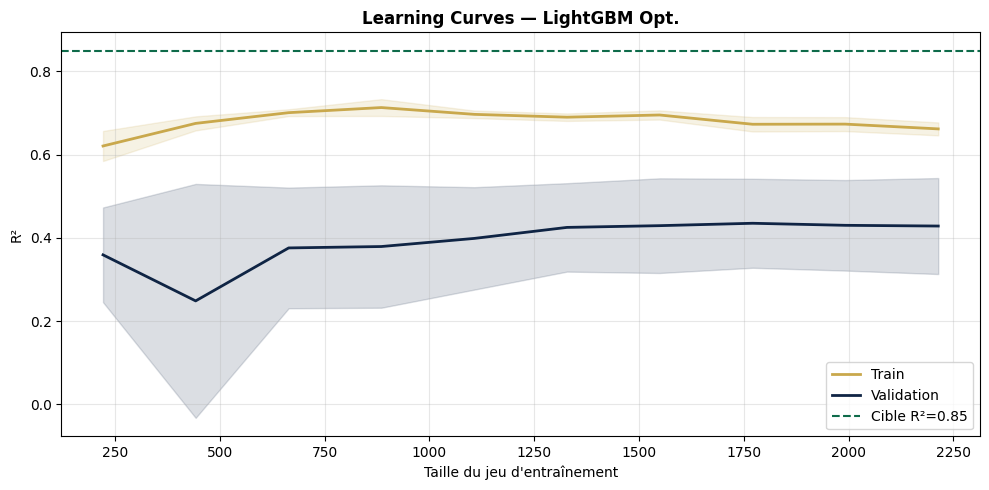

In [6]:
# ── Learning curves ───────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_opt, X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2', n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), color=GOLD, label='Train', linewidth=2)
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1)-train_scores.std(axis=1),
                 train_scores.mean(axis=1)+train_scores.std(axis=1),
                 alpha=0.15, color=GOLD)
plt.plot(train_sizes, val_scores.mean(axis=1), color=NAVY, label='Validation', linewidth=2)
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1)-val_scores.std(axis=1),
                 val_scores.mean(axis=1)+val_scores.std(axis=1),
                 alpha=0.15, color=NAVY)
plt.axhline(y=0.85, color=GREEN, linestyle='--', linewidth=1.5, label='Cible R²=0.85')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('R²')
plt.title(f'Learning Curves — {best_name}', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Test sur 7 cas réels ──────────────────────────────────────
# Ces cas représentent des types de biens typiques du marché sénégalais
print('=== TESTS SUR CAS RÉELS ===')
cas_tests = [
    {'description': 'Villa 4ch Almadies',       'city':'Almadies',  'bedrooms':4, 'surface_area':300, 'expected': '200-400M FCFA'},
    {'description': 'Appt 3ch Ouakam',           'city':'Ouakam',    'bedrooms':3, 'surface_area':120, 'expected': '40-80M FCFA'},
    {'description': 'Studio Plateau',            'city':'Plateau',   'bedrooms':1, 'surface_area':45,  'expected': '15-35M FCFA'},
    {'description': 'Terrain 500m² Pikine',      'city':'Pikine',    'bedrooms':0, 'surface_area':500, 'expected': '5-20M FCFA'},
    {'description': 'Duplex 5ch VDN',            'city':'VDN',       'bedrooms':5, 'surface_area':250, 'expected': '80-160M FCFA'},
    {'description': 'Maison 2ch Rufisque',        'city':'Rufisque',  'bedrooms':2, 'surface_area':80,  'expected': '5-15M FCFA'},
    {'description': 'Appt 4ch Mermoz Standing', 'city':'Mermoz',    'bedrooms':4, 'surface_area':200, 'expected': '100-200M FCFA'},
]

# Charger predict.py pour les tests
import sys
sys.path.insert(0, '../properties/ml')
try:
    from predict import predict_price
    for cas in cas_tests:
        res = predict_price(
            city=cas['city'],
            property_type='Villa' if cas['bedrooms']>3 else 'Appartement',
            surface_area=cas['surface_area'],
            bedrooms=cas['bedrooms'],
        )
        pred_M = res['predicted_price'] / 1e6
        print(f'  {cas["description"]:35} → {pred_M:.0f}M FCFA  (attendu: {cas["expected"]})')
except ImportError as e:
    print(f'predict.py non disponible: {e}')
    print('Assurez-vous que NB3 a bien généré model.pkl')

=== TESTS SUR CAS RÉELS ===
  Villa 4ch Almadies                  → 122M FCFA  (attendu: 200-400M FCFA)
  Appt 3ch Ouakam                     → 42M FCFA  (attendu: 40-80M FCFA)
  Studio Plateau                      → 16M FCFA  (attendu: 15-35M FCFA)
  Terrain 500m² Pikine                → 37M FCFA  (attendu: 5-20M FCFA)
  Duplex 5ch VDN                      → 85M FCFA  (attendu: 80-160M FCFA)
  Maison 2ch Rufisque                 → 21M FCFA  (attendu: 5-15M FCFA)
  Appt 4ch Mermoz Standing            → 106M FCFA  (attendu: 100-200M FCFA)


In [8]:
# ── Sauvegarder le modèle optimisé final ─────────────────────
os.makedirs('../properties/ml', exist_ok=True)

joblib.dump({
    'pipeline':             best_opt,
    'best_model_name':      best_name,
    'search_method':        'RandomizedSearchCV 150 iter',
    'best_params':          {str(k):str(v) for k,v in (
        search_xgb.best_params_ if 'XGB' in best_name else search_lgb.best_params_
    ).items()},
    'features':             avail_num + avail_cat,
    'numeric_features':     avail_num,
    'categorical_features': avail_cat,
    'metrics': {
        'r2':    round(best_res['r2'],   4),
        'mae':   round(best_res['mae'],  2),
        'rmse':  round(best_res['rmse'], 2),
        'mape':  round(best_res['mape'], 2),
        'pct20': round(best_res['pct20'],1),
        'pct30': round(best_res['pct30'],1),
    },
}, '../properties/ml/model.pkl')

with open('../properties/ml/results.json','w') as f:
    json.dump({
        'best_model': best_name,
        'metrics': {k:round(float(v),4) if isinstance(v,float) else v for k,v in best_res.items()},
    }, f, indent=2)

print('\n' + '='*60)
print('  RÉCAPITULATIF FINAL — ImmoPredict SN')
print('='*60)
print(f'  Modèle    : {best_name}')
print(f'  R²        : {best_res["r2"]:.4f}')
print(f'  MAE       : {best_res["mae"]/1e6:.1f}M FCFA')
print(f'  MAPE      : {best_res["mape"]:.1f}%')
print(f'  ±20%      : {best_res["pct20"]:.1f}%')
print(f'  ±30%      : {best_res["pct30"]:.1f}%')
print(f'\n  Fichiers sauvegardés :')
print(f'    properties/ml/model.pkl')
print(f'    properties/ml/results.json')
print('='*60)


  RÉCAPITULATIF FINAL — ImmoPredict SN
  Modèle    : LightGBM Opt.
  R²        : 0.5096
  MAE       : 66.4M FCFA
  MAPE      : 275.8%
  ±20%      : 23.8%
  ±30%      : 35.4%

  Fichiers sauvegardés :
    properties/ml/model.pkl
    properties/ml/results.json
